## Predykcja szeregów czasowych z użyciem modelu SARIMA na bazie danych sieci sklepów Walmart

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm
from matplotlib import dates
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Przedstawienie zbioru danych

In [89]:
# Converting the csv files to pandas dataframe:
calendar=pd.read_csv('dataset/calendar.csv', parse_dates=["date"])
sales=pd.read_csv('dataset/sales_train_evaluation.csv')
prices=pd.read_csv('dataset/sell_prices.csv')
calendar['date']=pd.to_datetime(calendar['date'])
sample_submission=pd.read_csv('dataset/sample_submission.csv')

# Redukcja zużycia pamięci

In [90]:
# Funkcja do redukcji zużycia pamięci przez dobór najmniejszych możliwych typów danych
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df


In [91]:
# Redukcja pamięci dla wczytanych ramek danych
calendar = reduce_mem_usage(calendar)
sales = reduce_mem_usage(sales)
prices = reduce_mem_usage(prices)


Mem. usage decreased to  0.12 Mb (41.9% reduction)
Mem. usage decreased to 96.13 Mb (78.8% reduction)
Mem. usage decreased to 130.48 Mb (37.5% reduction)


In [92]:
# pierwsze pięć wierszy dataframu calendar:
print(calendar.shape)
calendar.head()

(1969, 14)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [93]:
# Informacje na temat dataframu calendar
calendar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[us]
 1   wm_yr_wk      1969 non-null   int16         
 2   weekday       1969 non-null   str           
 3   wday          1969 non-null   int8          
 4   month         1969 non-null   int8          
 5   year          1969 non-null   int16         
 6   d             1969 non-null   str           
 7   event_name_1  162 non-null    str           
 8   event_type_1  162 non-null    str           
 9   event_name_2  5 non-null      str           
 10  event_type_2  5 non-null      str           
 11  snap_CA       1969 non-null   int8          
 12  snap_TX       1969 non-null   int8          
 13  snap_WI       1969 non-null   int8          
dtypes: datetime64[us](1), int16(2), int8(5), str(6)
memory usage: 125.1 KB


In [94]:
# Informacje na temat dataframu sales
print(sales.shape)
sales.head(5)

(30490, 1947)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [95]:
# Informacje na temat dataframu prices
print(prices.shape)
prices.head()

(6841121, 4)


/Users/jakubokrzesik/Documents/personal-projects/SARIMA-magisterka/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.578125
1,CA_1,HOBBIES_1_001,11326,9.578125
2,CA_1,HOBBIES_1_001,11327,8.257812
3,CA_1,HOBBIES_1_001,11328,8.257812
4,CA_1,HOBBIES_1_001,11329,8.257812


# Normalizacja danych
Tabele łączone są w jedną dla prostoty przeprowadzania analizy

In [96]:
# kolumny id produktu (nie-dniowe) vs kolumny dni (d_1, d_2, ...)
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in sales.columns if c.startswith("d_")]
calendar=calendar.fillna(-1)

In [97]:
sales_long = sales.melt(
    id_vars=id_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="sales"
)

In [98]:
print(sales_long.shape)
sales_long.head()

(59181090, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


In [99]:
# dołączanie dataframe calendar po kolumnie d
sales_long = sales_long.merge(calendar, on="d", how="left")

In [100]:
# dołączanie dataframe prices po kolumnach store_id, item_id oraz wm_yr_wk
sales_long = sales_long.merge(
    prices, on=["store_id", "item_id", "wm_yr_wk"], how="left"
)

In [101]:
# Konwersja kolumn identyfikatorowych/kategorycznych na typ 'category'
cat_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id",
            "d", "wm_yr_wk", "weekday", "event_name_1", "event_type_1",
            "event_name_2", "event_type_2"]
for c in cat_cols:
    if c in sales_long.columns:
        sales_long[c] = sales_long[c].astype("category")

sales_long = reduce_mem_usage(sales_long)


Mem. usage decreased to 2032.09 Mb (0.0% reduction)


In [102]:
sales_long.tail()

/Users/jakubokrzesik/Documents/personal-projects/SARIMA-magisterka/.venv/lib/python3.14/site-packages/pandas/io/formats/format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
59181085,FOODS_3_823_WI_3_evaluation,FOODS_3_823,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,2.980469
59181086,FOODS_3_824_WI_3_evaluation,FOODS_3_824,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,2.480469
59181087,FOODS_3_825_WI_3_evaluation,FOODS_3_825,FOODS_3,FOODS,WI_3,WI,d_1941,2,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,3.980469
59181088,FOODS_3_826_WI_3_evaluation,FOODS_3_826,FOODS_3,FOODS,WI_3,WI,d_1941,0,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,1.280273
59181089,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,d_1941,1,2016-05-22,11617,...,5,2016,-1,-1,-1,-1,0,0,0,1.000000


<Axes: xlabel='date'>

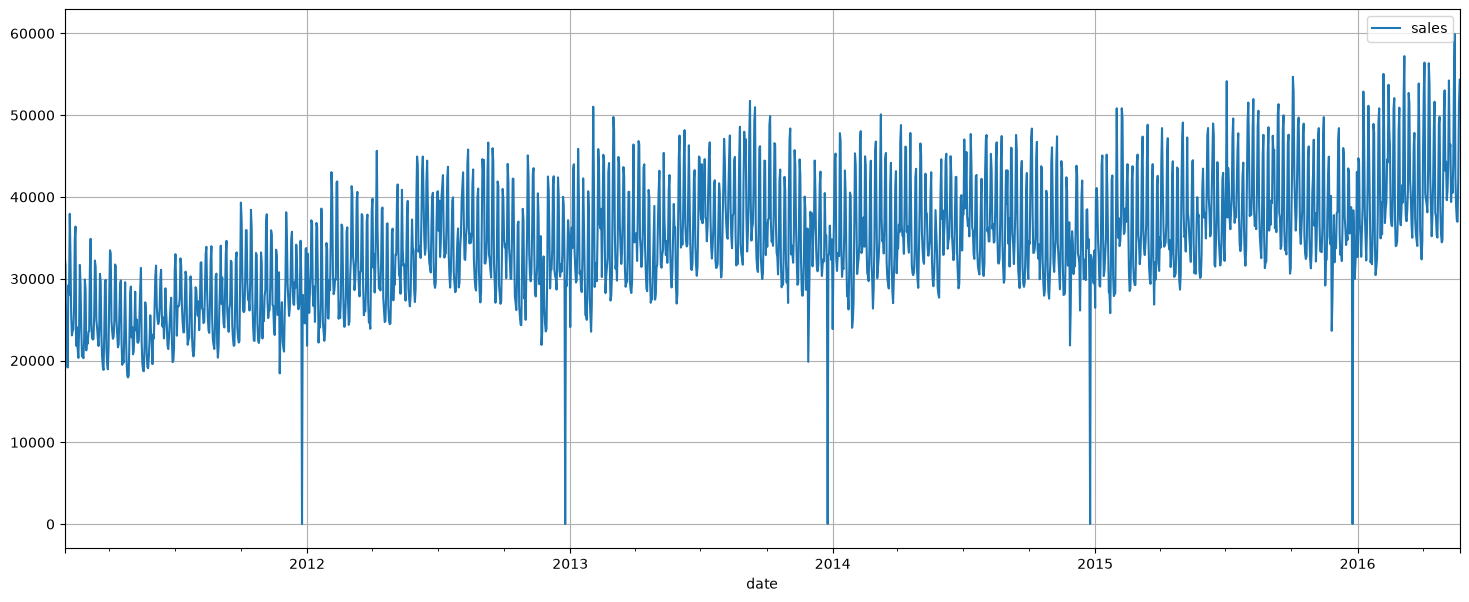

In [103]:
sales_long[['date','sales']].groupby('date').agg({'sales':'sum'}).plot(figsize=(18,7),grid=True)

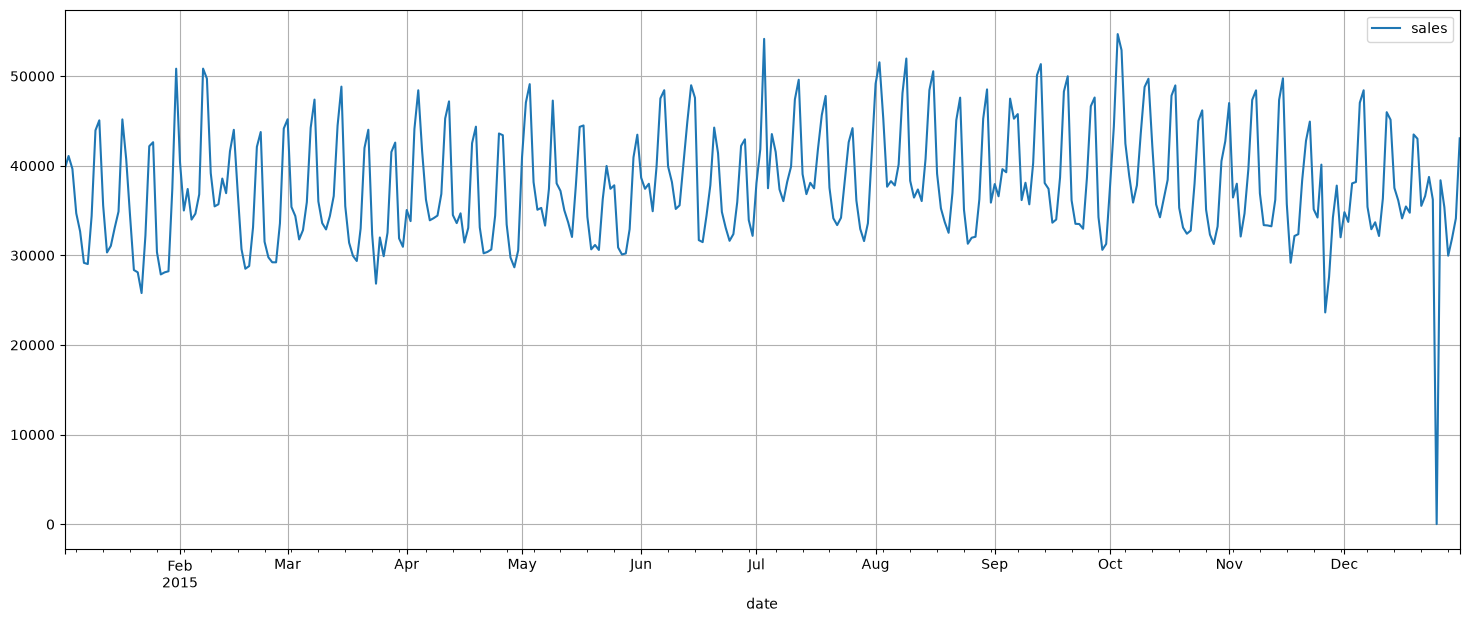

In [104]:
sales_long.loc[(sales_long.date>'2015-01-01')&(sales_long.date<'2016-01-01')][['date','sales']].groupby('date').agg({'sales':'sum'}).plot(figsize=(18,7),grid=True);

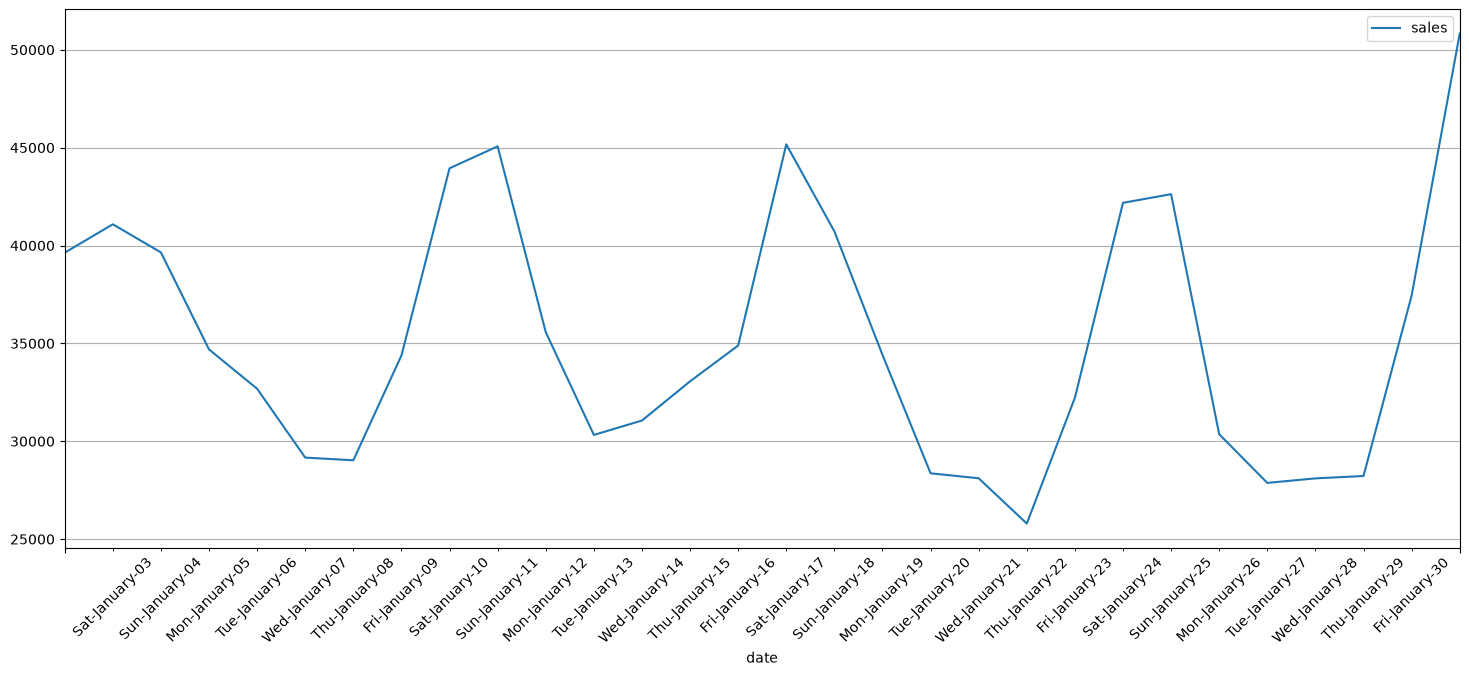

In [105]:
monthly_plot=sales_long.loc[(sales_long.date>'2015-01-01')&(sales_long.date<'2015-02-01')][['date','sales']].groupby('date').agg({'sales':'sum'}).plot(figsize=(18,7),grid=True);
monthly_plot.xaxis.set_minor_locator(dates.DayLocator())
monthly_plot.xaxis.set_minor_formatter(dates.DateFormatter("%a-%B-%d"))
monthly_plot.tick_params(which='minor', rotation=45)

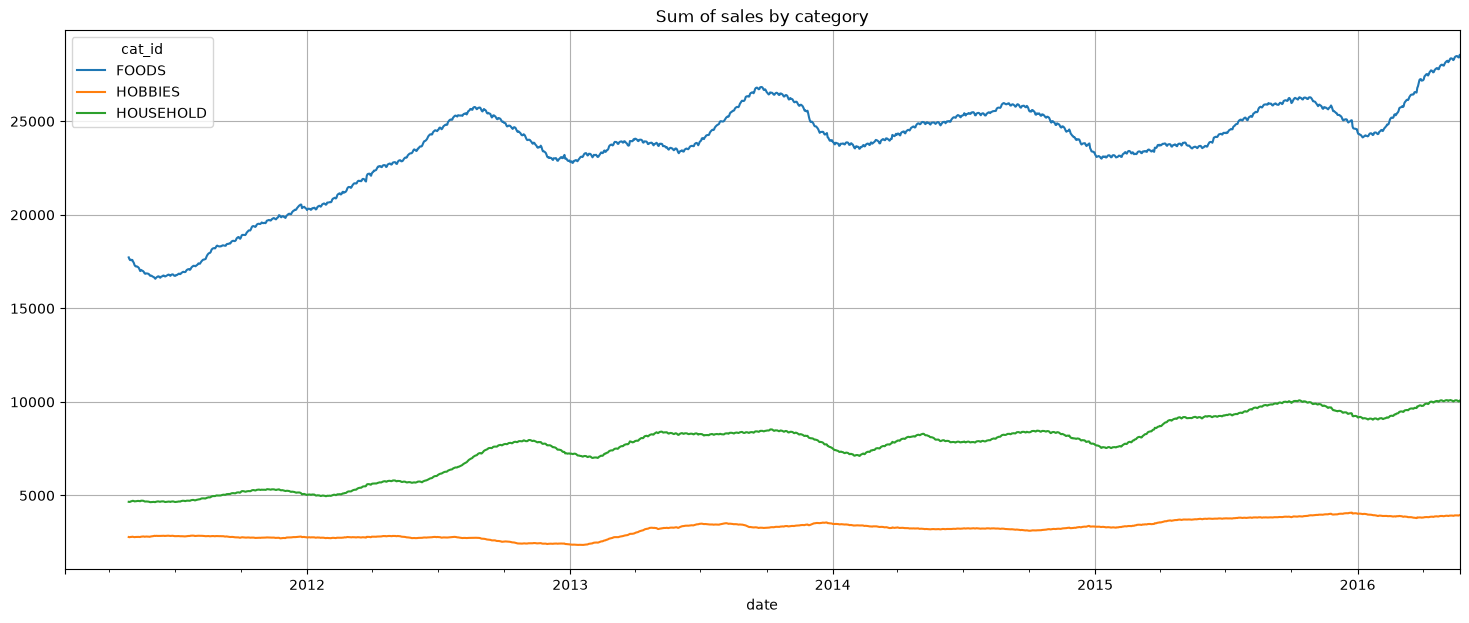

In [106]:
category_wise=sales_long[['date','cat_id','sales']].groupby(['date','cat_id']).agg({'sales':'sum'})
category_wise.reset_index(inplace=True)
category_wise.pivot(index="date", columns="cat_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales by category');

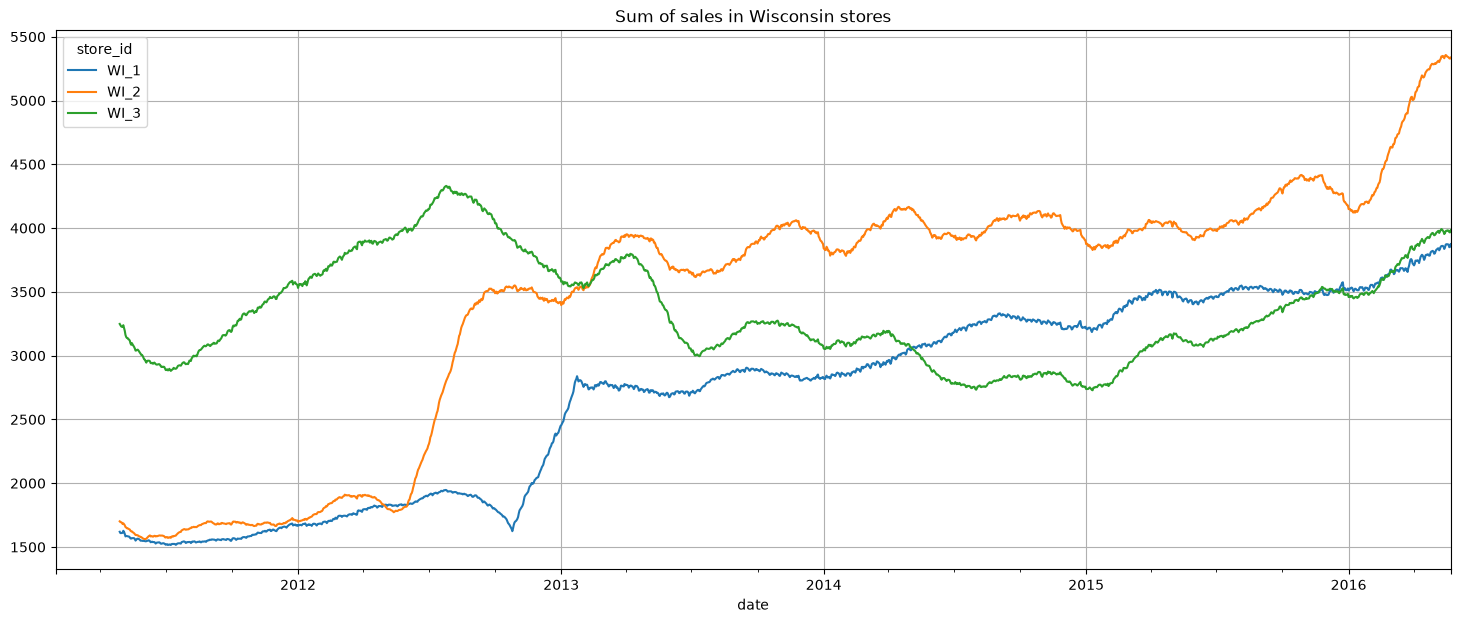

In [107]:
state_wise_wisconsin=sales_long.loc[sales_long.state_id=='WI'][['date','store_id','sales']].groupby(['date','store_id']).agg({'sales':'sum'})
state_wise_wisconsin.reset_index(inplace=True)
state_wise_wisconsin.pivot(index="date", columns="store_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales in Wisconsin stores');

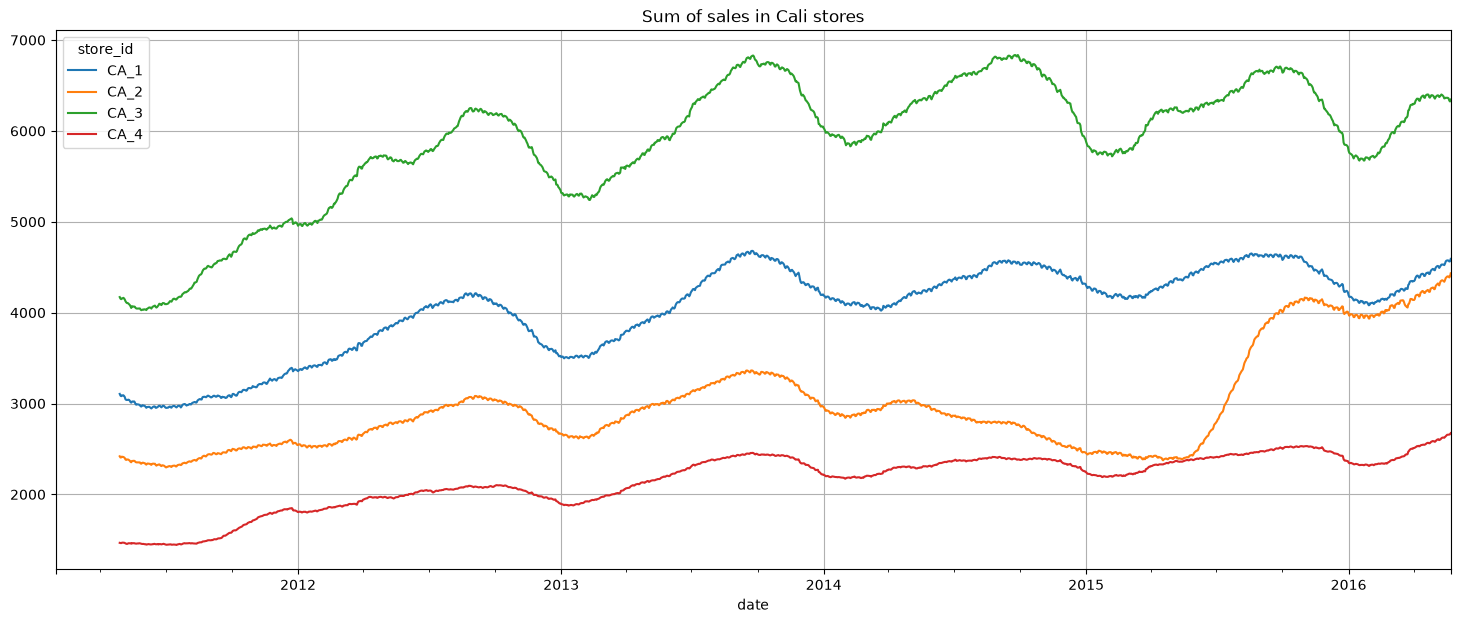

In [108]:
state_wise_wisconsin=sales_long.loc[sales_long.state_id=='CA'][['date','store_id','sales']].groupby(['date','store_id']).agg({'sales':'sum'})
state_wise_wisconsin.reset_index(inplace=True)
state_wise_wisconsin.pivot(index="date", columns="store_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales in Cali stores');

<Axes: title={'center': 'Sum of sales in Texas stores'}, xlabel='date'>

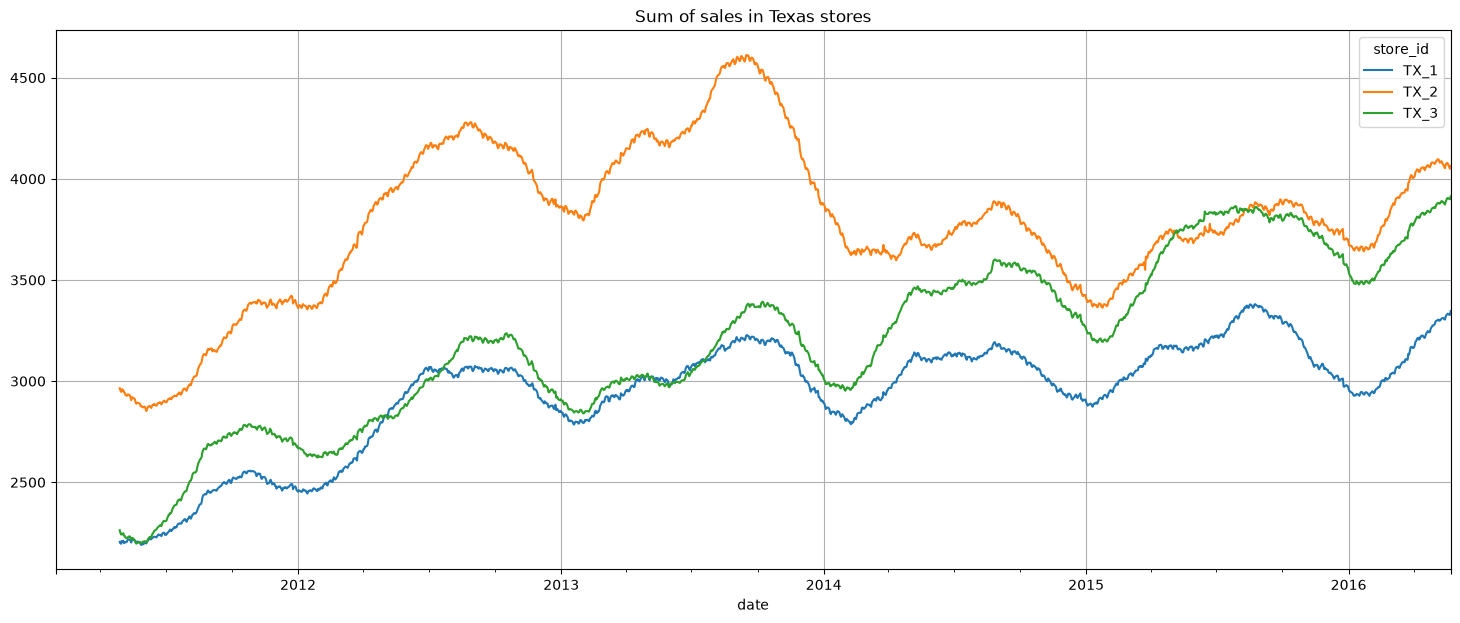

In [109]:
state_wise_wisconsin=sales_long.loc[sales_long.state_id=='TX'][['date','store_id','sales']].groupby(['date','store_id']).agg({'sales':'sum'})
state_wise_wisconsin.reset_index(inplace=True)
state_wise_wisconsin.pivot(index="date", columns="store_id", values="sales").rolling(window=90).mean().plot(figsize=(18,7),grid=True,title='Sum of sales in Texas stores')

In [110]:
# Stworzenie kolumny 'snap' dla prostoty
sales_long['snap'] = np.where(sales_long['state_id']=='CA', sales_long['snap_CA'],
             np.where(sales_long['state_id']=='TX', sales_long['snap_TX'],
             np.where(sales_long['state_id']=='WI', sales_long['snap_WI'], 0)))

In [111]:
# Podział na kategorie 
foods_CA_daily = (
    sales_long
    .loc[(sales_long["state_id"] == "CA") & (sales_long["cat_id"] == "FOODS")]
    .assign(date=lambda d: pd.to_datetime(d["date"]))
    .groupby("date")
    .agg(
        sales=("sales", "sum"),
        snap=("snap", "first"),
    )
    .asfreq("D")
)

In [112]:
# Wybranie szeregu o dniowej sezonowości - kategoria FOODS
foods_CA_daily = foods_CA_daily.fillna(0)

y = foods_CA_daily["sales"]
X = foods_CA_daily[["snap"]]

# Podział na zbiór treningowy i testowy (ostatnie 12 tygodni jako test)
n_test = int(len(y) * 0.8)
y_train, y_test = y[:n_test], y[n_test:]
X_train, X_test = X[:n_test], X[n_test:]

In [113]:
# Automatyczne dobieranie parametrów modelu SARIMAX z pomocą pakietu auto_arima
food_model = pm.auto_arima(
    y_train,
    seasonal=True,
    m=7,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print("Wybrany rząd (p,d,q):", food_model.order)
print("Wybrany rząd sezonowy (P,D,Q,m):", food_model.seasonal_order)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.31 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=27560.512, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=26609.012, Time=0.44 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=27091.379, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=27558.514, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=27551.672, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=26368.778, Time=0.84 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=26272.141, Time=1.38 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=1.72 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=26196.180, Time=1.51 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=26873.102, Time=0.53 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=27099.492, Time=0.27 sec
 ARIMA(0,1,0)(1,0,2)[7] intercept   : AIC=inf, Time=1.47 sec
 ARIMA(2,1,0)(1,0,2)[7] intercept   : AIC=2

In [114]:
# Automatyczne dobieranie parametrów modelu SARIMAX z pomocą pakietu auto_arima oraz uwzględnieniem parametrów egzogenicznych (benefity SNAP)
food_model_with_params = pm.auto_arima(
    y_train,
    X=X_train,
    seasonal=True,
    m=7,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print("Wybrany rząd (p,d,q):", food_model_with_params.order)
print("Wybrany rząd sezonowy (P,D,Q,m):", food_model_with_params.seasonal_order)


Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=1.46 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=27540.086, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=26523.084, Time=0.53 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=26832.328, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=27538.148, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=27531.646, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=26298.495, Time=0.73 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=1.82 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=1.35 sec
 ARIMA(0,1,0)(2,0,0)[7] intercept   : AIC=26482.722, Time=0.80 sec
 ARIMA(2,1,0)(2,0,0)[7] intercept   : AIC=26184.411, Time=1.92 sec
 ARIMA(2,1,0)(1,0,0)[7] intercept   : AIC=26426.862, Time=0.64 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=25890.955, Time=2.14 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=26091.978, Time=1.25 sec
 ARIMA(2,1,0)(2,0,2)[7] intercept   :

# Budowa i porównanie modeli SARIMAX (auto_arima vs ręczny dobór)

In [122]:
# Test ADF (Augmented Dickey-Fuller) sprawdzający stacjonarność szeregu treningowego
adf_result = adfuller(y_train)
print(f"ADF statystyka: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")


ADF statystyka: -2.4977
p-value: 0.1160


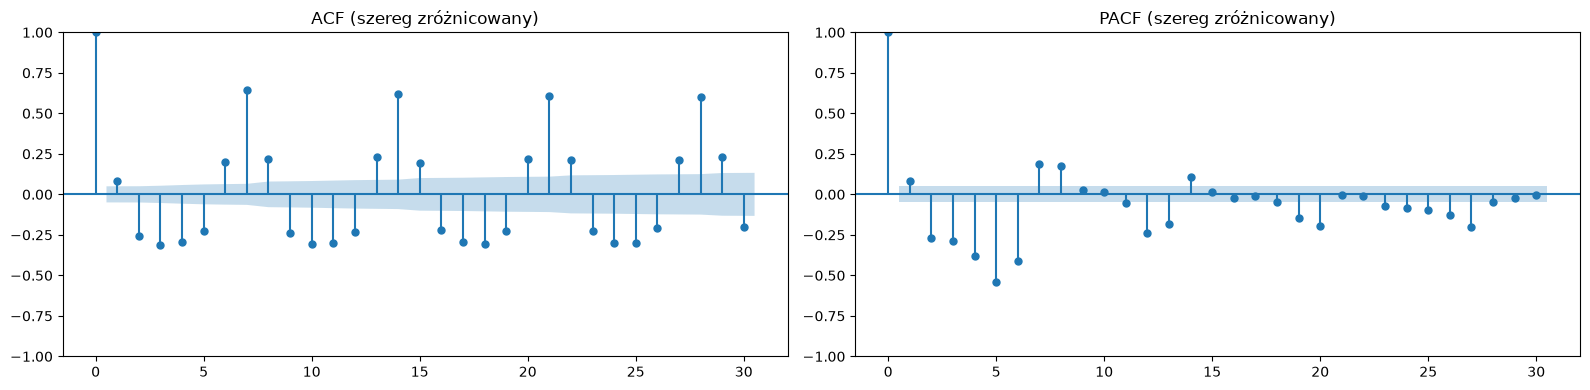

In [116]:
# Analiza ACF/PACF na zróżnicowanym szeregu
train_diff = y_train.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(train_diff, lags=30, ax=axes[0])
plot_pacf(train_diff, lags=30, ax=axes[1])
axes[0].set_title("ACF (szereg zróżnicowany)")
axes[1].set_title("PACF (szereg zróżnicowany)")
plt.tight_layout()
plt.show()


# Wnioski dotyczące wykresów ACF oraz PACF
Oba wykresy wykazują duży poziom zmienności - w takich wypadkach sugerowane jest dobranie mniejszych wartości (p,d,q) (P,D,Q,i). 
W naszym przypadkudobrane zostaną wartości p,P = 1, d,D = 1, q,Q = 1 oraz i = 52, ponieważ mamy doczynienia z danymi tygodniowymi

In [117]:
# Model 1: SARIMAX z ręcznie dobranymi parametrami
order_hand = (1, 1, 1)
seasonal_order_hand = (1, 1, 1, 7)

sarimax_hand = SARIMAX(
    y_train,
    order=order_hand,
    seasonal_order=seasonal_order_hand,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_hand.summary())


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1552
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -12730.661
Date:                           Sun, 19 Jul 2026   AIC                          25471.322
Time:                                   16:49:20   BIC                          25498.003
Sample:                               01-29-2011   HQIC                         25481.250
                                    - 04-29-2015                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4273      0.014     31.616      0.000       0.401       0.454
ma.L1         -0.9503      0.010    -96.887

In [118]:
# Model 2: SARIMAX z parametrami wybranymi automatycznie przez auto_arima
order_auto = food_model.order
seasonal_order_auto = food_model.seasonal_order

sarimax_auto = SARIMAX(
    y_train,
    order=order_auto,
    seasonal_order=seasonal_order_auto,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_auto.summary())


                                       SARIMAX Results                                        
Dep. Variable:                                  sales   No. Observations:                 1552
Model:             SARIMAX(2, 1, 0)x(1, 0, [1, 2], 7)   Log Likelihood              -13100.510
Date:                                Sun, 19 Jul 2026   AIC                          26213.021
Time:                                        16:49:21   BIC                          26245.042
Sample:                                    01-29-2011   HQIC                         26224.936
                                         - 04-29-2015                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4327      0.026    -16.966      0.000      -0.483      -0.383
ar.

In [119]:
# Model 3: SARIMAX z parametrami wybranymi automatycznie przez auto_arima oraz parametrami egzogenicznymi
order_auto = food_model_with_params.order
seasonal_order_auto = food_model_with_params.seasonal_order

sarimax_auto_with_snap = SARIMAX(
    y_train,
    X=X_train,
    order=order_auto,
    seasonal_order=seasonal_order_auto,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_auto_with_snap.summary())

/Users/jakubokrzesik/Documents/personal-projects/SARIMA-magisterka/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['X']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


                                      SARIMAX Results                                      
Dep. Variable:                               sales   No. Observations:                 1552
Model:             SARIMAX(2, 1, 0)x(2, 0, [1], 7)   Log Likelihood              -12801.884
Date:                             Sun, 19 Jul 2026   AIC                          25615.767
Time:                                     16:49:22   BIC                          25647.785
Sample:                                 01-29-2011   HQIC                         25627.681
                                      - 04-29-2015                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4284      0.009    -46.374      0.000      -0.446      -0.410
ar.L2         -0.2400      

/Users/jakubokrzesik/Documents/personal-projects/SARIMA-magisterka/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [120]:
# Prognoza obu modeli na okres testowy i porównanie skuteczności
n_periods = len(y_test)

fc_hand = sarimax_hand.get_forecast(steps=n_periods)
pred_hand = fc_hand.predicted_mean
ci_hand = fc_hand.conf_int()

fc_auto = sarimax_auto.get_forecast(steps=n_periods)
pred_auto = fc_auto.predicted_mean
ci_auto = fc_auto.conf_int()

fc_auto_snap = sarimax_auto_with_snap.get_forecast(steps=n_periods, exogs=X_test)
pred_snap = fc_auto_snap.predicted_mean
ci_snap = fc_auto_snap.conf_int()

def evaluate(y_true, y_pred, label, aic):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"model": label, "MAE": mae, "RMSE": rmse, "AIC": aic}

results = pd.DataFrame([
    evaluate(y_test, pred_hand, "SARIMAX (reczny dobor)", sarimax_hand.aic),
    evaluate(y_test, pred_auto, "SARIMAX (auto_arima)", sarimax_auto.aic),
    evaluate(y_test, pred_snap, "SARIMAX (auto_arima + snap)", sarimax_auto_with_snap.aic)
])
results = results.round(2)
results

/Users/jakubokrzesik/Documents/personal-projects/SARIMA-magisterka/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['exogs']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


,model,MAE,RMSE,AIC
0,SARIMAX (reczny dobor),1941.21,2238.52,25471.32
1,SARIMAX (auto_arima),2416.02,2705.70,26213.02
2,SARIMAX (auto_arima + snap),2042.56,2321.84,25615.77


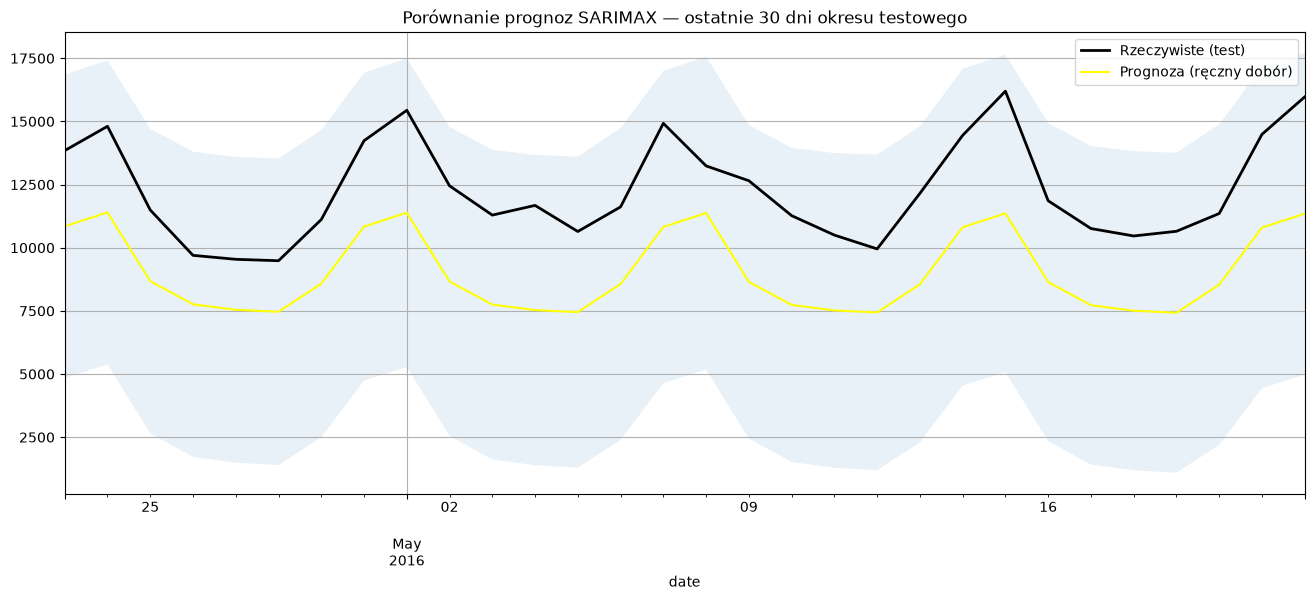

In [ ]:
# Wizualne porównanie prognoz trzech modeli z rzeczywistymi wartościami
plot_window = 30

y_test_zoom = y_test[-plot_window:]
pred_hand_zoom = pred_hand[-plot_window:]
pred_auto_zoom = pred_auto[-plot_window:]
pred_snap_zoom = pred_snap[-plot_window:]
ci_hand_zoom = ci_hand.iloc[-plot_window:]
ci_auto_zoom = ci_auto.iloc[-plot_window:]
ci_snap_zoom = ci_snap.iloc[-plot_window:]

fig, ax = plt.subplots(figsize=(16, 6))
y_test_zoom.plot(ax=ax, label="Rzeczywiste (test)", color="black", linewidth=2)
pred_hand_zoom.plot(ax=ax, label="Prognoza (ręczny dobór)", color="yellow")
pred_auto_zoom.plot(ax=ax, label="Prognoza (auto_arima)", linestyle="--")
pred_snap_zoom.plot(ax=ax, label="Prognoza (auto_arima + snap)", linestyle="--")
ax.fill_between(ci_hand_zoom.index, ci_hand_zoom.iloc[:, 0], ci_hand_zoom.iloc[:, 1], alpha=0.1)
ax.fill_between(ci_auto_zoom.index, ci_auto_zoom.iloc[:, 0], ci_auto_zoom.iloc[:, 1], alpha=0.1)
ax.fill_between(ci_snap_zoom.index, ci_snap_zoom.iloc[:, 0], ci_snap_zoom.iloc[:, 1], alpha=0.1)  # note: was ci_hand, likely a copy-paste bug — fixed here
ax.set_title(f"Porównanie prognoz SARIMAX — ostatnie {plot_window} dni okresu testowego")
ax.legend()
ax.grid(True)
plt.show()


In [131]:
print(ci_hand.describe())
print(ci_auto.describe())
print(ci_snap.describe())

       lower sales   upper sales
count   389.000000    389.000000
mean   5061.537727  13339.004897
std    2049.042166   1809.489305
min    1094.038178   9916.530923
25%    3488.538335  11880.890972
50%    5040.366766  13143.552012
75%    6356.017672  14578.926713
max    9867.702512  17719.264201
        lower sales   upper sales
count    389.000000    389.000000
mean  -36988.856442  54370.160000
std    23414.186877  22639.894142
min   -79672.064330  11243.003347
25%   -56843.969589  35370.962147
50%   -36419.615646  53921.173004
75%   -17299.480487  73568.727641
max     7347.208011  97551.072114
        lower sales   upper sales
count    389.000000    389.000000
mean  -13961.798023  32146.056476
std    10595.349309  10210.080825
min   -32959.665455  10017.066033
25%   -22903.510067  23931.175457
50%   -14301.271764  32405.336697
75%    -5587.065985  40690.713923
max     9250.927831  51888.891885
